# **1. 드라이브 연결**

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


# **2. 모델 및 함수 정의**

In [3]:
import os
import pandas as pd
import torch
import torch.nn as nn
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# GPU/CPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")


# CasualConv1d layer
# 과거-현재 데이터만 보고 특징을 추출함
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super(CausalConv1d, self).__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,
                              padding=self.padding, dilation=dilation)

    def forward(self, x):
        x = self.conv(x)
        return x[:, :, :-self.padding]

class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=3, dropout=0.2):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [
                CausalConv1d(in_channels, out_channels, kernel_size, dilation=dilation_size),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

class TRACE_GPT(nn.Module):
    def __init__(self, num_sensors, seq_len, d_model=128, n_head=8, num_layers=6, resolution=100, dropout=0.1):
        super(TRACE_GPT, self).__init__()
        self.num_sensors = num_sensors
        self.seq_len = seq_len
        self.resolution = resolution
        self.d_model = d_model

        # TCN 4층 (Receptive Field 확보)
        tcn_channels = [d_model] * 4

        self.tcn = TemporalConvNet(
            num_inputs=num_sensors + 1, # +1 for Time Index
            num_channels=tcn_channels,
            kernel_size=3,
            dropout=dropout
        )

        self.transformer_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=n_head, batch_first=True, dropout=dropout),
            num_layers=num_layers
        )

        self.output_head = nn.Linear(d_model, num_sensors * resolution)

    def _generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, x):
        batch_size, curr_seq_len, _ = x.size()

        # Positional Embedding
        steps = torch.arange(curr_seq_len, device=x.device, dtype=torch.float32)
        time_idx = (steps / self.seq_len).unsqueeze(0).unsqueeze(2)
        time_idx = time_idx.expand(batch_size, -1, -1)

        x_emb = torch.cat([x, time_idx], dim=2)

        x_tcn = x_emb.permute(0, 2, 1)
        x_tcn = self.tcn(x_tcn)
        x_tcn = x_tcn.permute(0, 2, 1)

        tgt_mask = self._generate_square_subsequent_mask(curr_seq_len).to(x.device)
        output = self.transformer_encoder(x_tcn, mask=tgt_mask, is_causal=True)

        logits = self.output_head(output)
        logits = logits.view(batch_size, curr_seq_len, self.num_sensors, self.resolution)

        return logits


def preprocess_and_window(df_wafer, sensor_cols, seq_len, scaler):
    """실시간 Raw 데이터를 스케일링하고 슬라이딩 윈도우 텐서로 변환"""
    data_values = df_wafer[sensor_cols].values
    data_scaled = scaler.transform(data_values) # 저장된 scaler로 변환

    sequences = []
    if len(data_scaled) < seq_len:
        print(f"⚠️ 데이터 길이가 시퀀스 길이({seq_len})보다 짧아 처리할 수 없습니다.")
        return None

    for i in range(len(data_scaled) - seq_len + 1):
        sequences.append(data_scaled[i : i + seq_len])

    return torch.FloatTensor(np.array(sequences)) # [Window_Num, 32, 19]


# 변환 함수
# 0~1 사이의 실수 데이터를 0~99 사이의 정수 데이터로 변환
def quantize_data(x, resolution=100):
    x_idx = (x * (resolution - 1)).long()
    x_idx = torch.clamp(x_idx, 0, resolution - 1)
    return x_idx


# 학습 함수
def train_trace_gpt(model, train_loader, optimizer, epoch, device, resolution=100):
    model.train()
    total_loss = 0
    criterion = nn.CrossEntropyLoss()

    for (data,) in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        # Input(0~T-1) -> Target(1~T): 데이터 분할
        input_seq = data[:, :-1, :]
        target_seq = data[:, 1:, :]
        target_idx = quantize_data(target_seq, resolution)

        output_logits = model(input_seq)

        # loss 계산 (모델의 예측과 실제 정답 간의 차이)
        loss = criterion(
            output_logits.reshape(-1, resolution),
            target_idx.reshape(-1)
        )
        # 가중치 업데이트
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 10 == 0: # 10 epoch마다 로그 출력
        print(f"Epoch [{epoch+1}] Loss: {avg_loss:.4f}")
    return avg_loss

def trace_calculate_window_scores(model, data_tensor, device, batch_size=32, resolution=100):
    model.eval()
    all_scores = []
    criterion = nn.CrossEntropyLoss(reduction='none')   # loss 계산

    dataset = TensorDataset(data_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (data,) in loader:
            data = data.to(device)
            input_seq = data[:, :-1, :]   # 입력 데이터
            target_seq = data[:, 1:, :]   # 정답 데이터
            target_idx = quantize_data(target_seq, resolution)    # 정답 데이터를 0~99로 변환

            output_logits = model(input_seq)    # 모델이 예측한 확률값

            loss_element = criterion(
                output_logits.reshape(-1, resolution),
                target_idx.reshape(-1)
            )
            loss_element = loss_element.view(input_seq.shape[0], input_seq.shape[1], input_seq.shape[2])

            # Window별 평균 Loss
            score_window = loss_element.mean(dim=[1, 2])
            all_scores.extend(score_window.cpu().numpy())

    return np.array(all_scores)



def trace_calculate_rca_scores(model, data_tensor, device, batch_size=32, resolution=100):
    model.eval()
    all_scores = []
    criterion_none = nn.CrossEntropyLoss(reduction='none')
    loader = DataLoader(TensorDataset(data_tensor), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for (data,) in loader:
            data = data.to(device)
            input_seq, target_seq = data[:, :-1, :], data[:, 1:, :]
            target_idx = quantize_data(target_seq, resolution)
            logits = model(input_seq)
            loss_elem = criterion_none(logits.reshape(-1, resolution), target_idx.reshape(-1))
            loss_elem = loss_elem.view(input_seq.shape[0], input_seq.shape[1], input_seq.shape[2])
            all_scores.append(loss_elem.mean(dim=1).cpu().numpy()) # [시간] 축만 평균, [센서] 차원 보존
    return np.concatenate(all_scores, axis=0)

def analyze_single_wafer(model, wafer_tensor, wafer_id, threshold, sensor_cols, device, resolution=100):
    print(f"\n" + "="*55)
    print(f" 🏭 Wafer Analysis Report: [ {wafer_id} ]")
    print("="*55)

    window_scores = trace_calculate_window_scores(model, wafer_tensor, device, batch_size=32, resolution=resolution)
    wafer_score = np.max(window_scores)

    print(f"▶ Wafer Anomaly Score: {wafer_score:.4f} (기준 임계값: {threshold:.4f})")

    if wafer_score > threshold:
        print(f"▶ 판정: 불량 (Fault) 감지")
        print("-" * 55)
        print("[Root Cause Analysis]")

        rca_scores = trace_calculate_rca_scores(model, wafer_tensor, device, batch_size=32, resolution=resolution)
        wafer_sensor_scores = rca_scores.mean(axis=0)

        top_k = 5
        top_indices = np.argsort(wafer_sensor_scores)[::-1][:top_k]
        top_sensors = [sensor_cols[i] for i in top_indices]
        top_scores = wafer_sensor_scores[top_indices]

        plt.figure(figsize=(8, 4))
        sns.barplot(x=top_scores, y=top_sensors, palette='Reds_r')
        plt.title(f"RCA - Top {top_k} Anomalous Sensors ({wafer_id})", fontweight='bold')
        plt.xlabel("Anomaly Score (Loss)")
        plt.ylabel("Sensors")
        plt.tight_layout()
        plt.show()

        for i, (sensor, score) in enumerate(zip(top_sensors, top_scores)):
            print(f"  {i+1}위. {sensor}: {score:.4f}")
    else:
        print(f"▶ 판정: ✅ 정상 (Normal)")
        print("▶ 해당 웨이퍼는 안정적인 공정 패턴을 보입니다. (RCA 생략)")

✅ Using device: cpu


# **3. 예측 실행**

 거대 원본 데이터 로드 중 (1회만 수행됩니다): /content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx
 원본 데이터 로드 완료!


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [l29] 실험군 전체 테스트셋 분석 시작
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ 모델 로드 성공! (Threshold: 3.1763)
▶ 타겟 데이터: 정상 14개 | 불량 9개 (총 분석 대상: 23개)


 [1/23] 웨이퍼 검사: l2915.txm

 🏭 Wafer Analysis Report: [ l2915.txm ]
▶ Wafer Anomaly Score: 4.7315 (기준 임계값: 3.1763)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


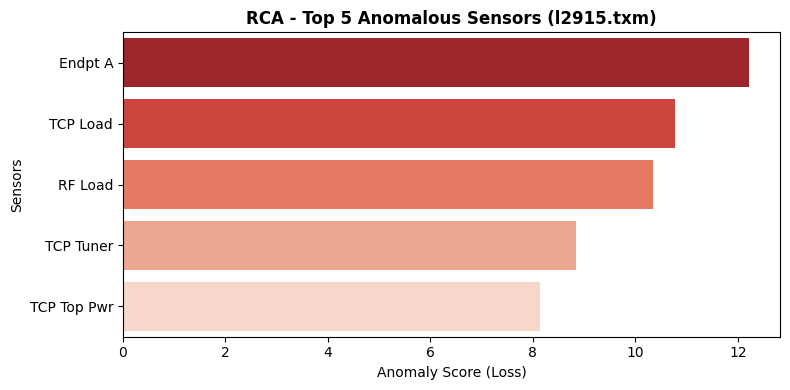

  1위. Endpt A: 12.2123
  2위. TCP Load: 10.7659
  3위. RF Load: 10.3381
  4위. TCP Tuner: 8.8471
  5위. TCP Top Pwr: 8.1425

 [2/23] 웨이퍼 검사: l2916.txm

 🏭 Wafer Analysis Report: [ l2916.txm ]
▶ Wafer Anomaly Score: 3.5474 (기준 임계값: 3.1763)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


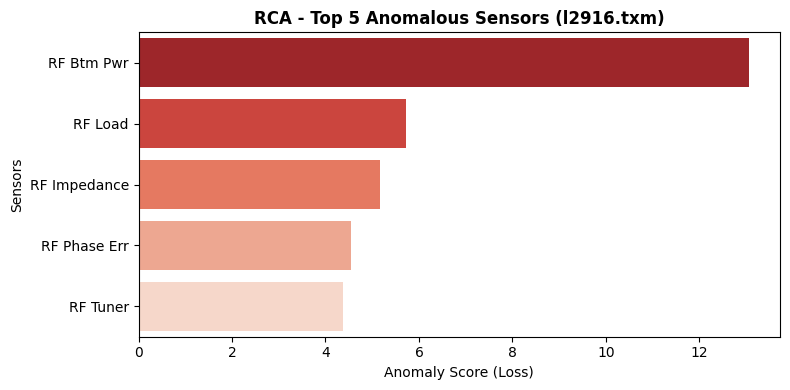

  1위. RF Btm Pwr: 13.0718
  2위. RF Load: 5.7212
  3위. RF Impedance: 5.1680
  4위. RF Phase Err: 4.5508
  5위. RF Tuner: 4.3815

 [3/23] 웨이퍼 검사: l2917.txm

 🏭 Wafer Analysis Report: [ l2917.txm ]
▶ Wafer Anomaly Score: 3.4370 (기준 임계값: 3.1763)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


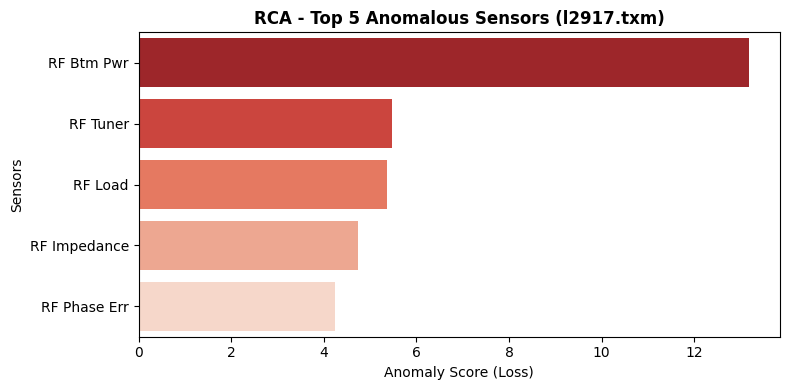

  1위. RF Btm Pwr: 13.1934
  2위. RF Tuner: 5.4784
  3위. RF Load: 5.3705
  4위. RF Impedance: 4.7321
  5위. RF Phase Err: 4.2381

 [4/23] 웨이퍼 검사: l2918.txm

 🏭 Wafer Analysis Report: [ l2918.txm ]
▶ Wafer Anomaly Score: 5.0348 (기준 임계값: 3.1763)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


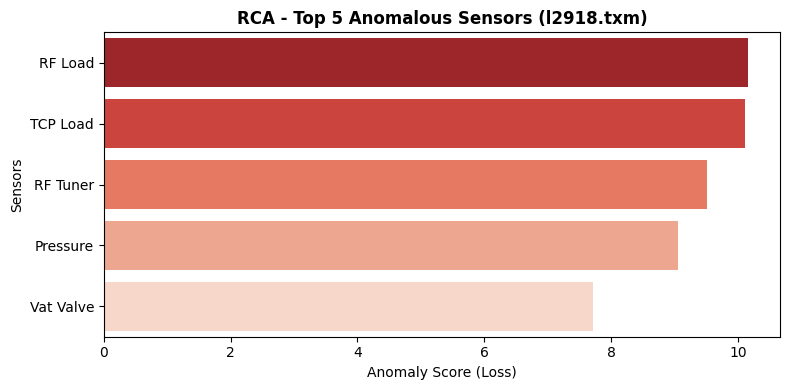

  1위. RF Load: 10.1570
  2위. TCP Load: 10.1204
  3위. RF Tuner: 9.5167
  4위. Pressure: 9.0591
  5위. Vat Valve: 7.7234
  ✅ [5/23] l2925.txm : 정상 통과 (Score: 2.6191)
  ✅ [6/23] l2926.txm : 정상 통과 (Score: 2.5561)
  ✅ [7/23] l2927.txm : 정상 통과 (Score: 2.6029)
  ✅ [8/23] l2928.txm : 정상 통과 (Score: 2.5467)
  ✅ [9/23] l2929.txm : 정상 통과 (Score: 2.6597)
  ✅ [10/23] l2930.txm : 정상 통과 (Score: 2.6830)
  ✅ [11/23] l2931.txm : 정상 통과 (Score: 2.5330)
  ✅ [12/23] l2932.txm : 정상 통과 (Score: 3.1465)
  ✅ [13/23] l2933.txm : 정상 통과 (Score: 2.5466)
  ✅ [14/23] l2934.txm : 정상 통과 (Score: 2.7034)
  ✅ [15/23] l2935.txm : 정상 통과 (Score: 2.5684)

 [16/23] 웨이퍼 검사: l2936.txm

 🏭 Wafer Analysis Report: [ l2936.txm ]
▶ Wafer Anomaly Score: 4.0121 (기준 임계값: 3.1763)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


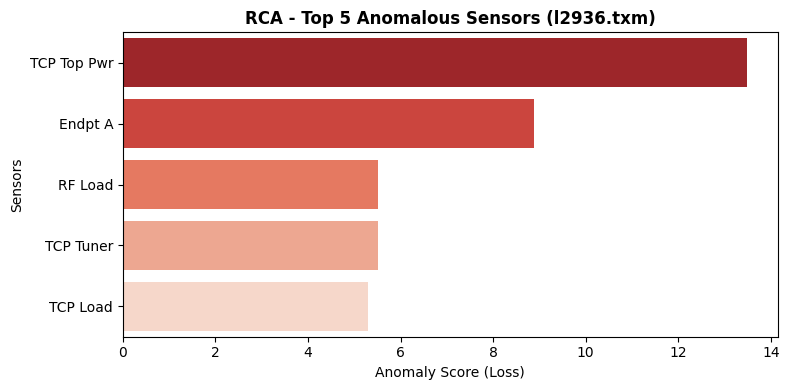

  1위. TCP Top Pwr: 13.4769
  2위. Endpt A: 8.8902
  3위. RF Load: 5.5141
  4위. TCP Tuner: 5.5109
  5위. TCP Load: 5.2956

 [17/23] 웨이퍼 검사: l2937.txm

 🏭 Wafer Analysis Report: [ l2937.txm ]
▶ Wafer Anomaly Score: 3.3793 (기준 임계값: 3.1763)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


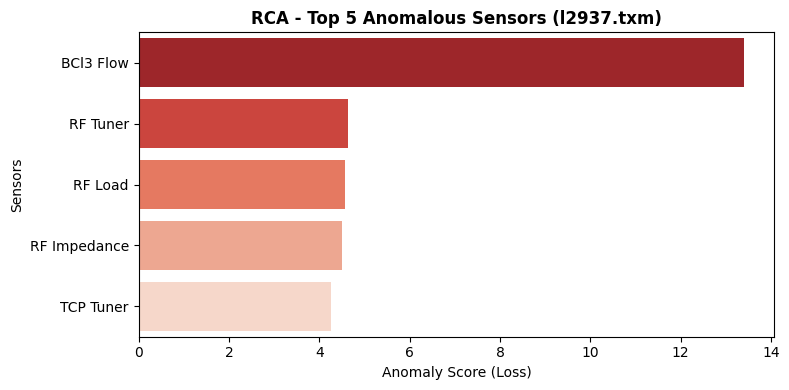

  1위. BCl3 Flow: 13.4040
  2위. RF Tuner: 4.6305
  3위. RF Load: 4.5690
  4위. RF Impedance: 4.4966
  5위. TCP Tuner: 4.2610

 [18/23] 웨이퍼 검사: l2938.txm

 🏭 Wafer Analysis Report: [ l2938.txm ]
▶ Wafer Anomaly Score: 4.6072 (기준 임계값: 3.1763)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


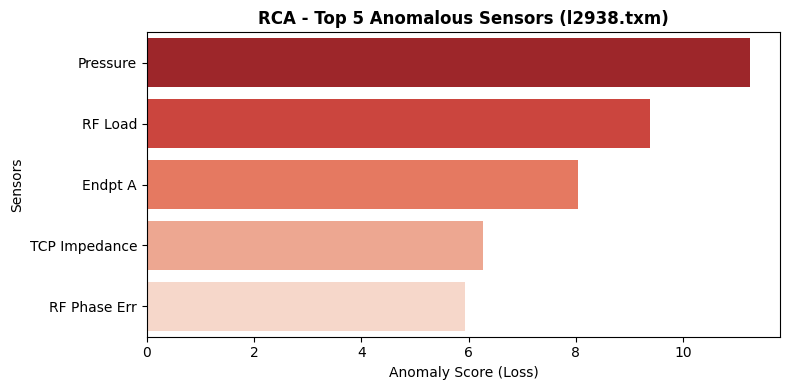

  1위. Pressure: 11.2430
  2위. RF Load: 9.3782
  3위. Endpt A: 8.0426
  4위. TCP Impedance: 6.2673
  5위. RF Phase Err: 5.9361

 [19/23] 웨이퍼 검사: l2939.txm

 🏭 Wafer Analysis Report: [ l2939.txm ]
▶ Wafer Anomaly Score: 3.7732 (기준 임계값: 3.1763)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


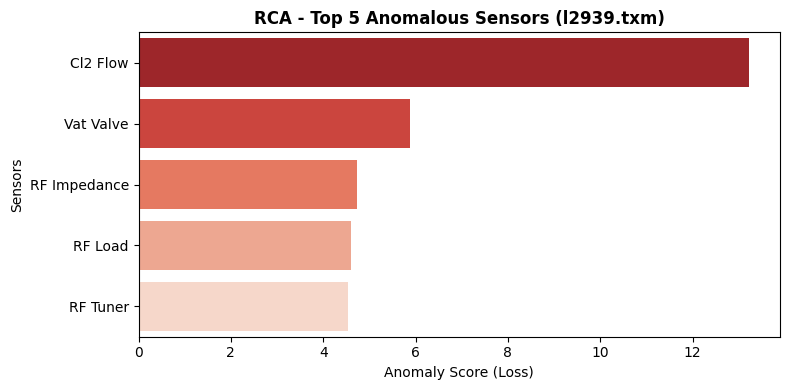

  1위. Cl2 Flow: 13.2335
  2위. Vat Valve: 5.8900
  3위. RF Impedance: 4.7403
  4위. RF Load: 4.6101
  5위. RF Tuner: 4.5271

 [20/23] 웨이퍼 검사: l2940.txm

 🏭 Wafer Analysis Report: [ l2940.txm ]
▶ Wafer Anomaly Score: 3.2578 (기준 임계값: 3.1763)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


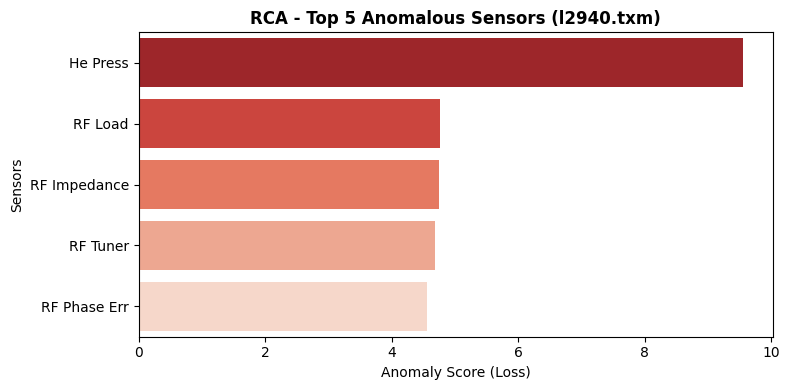

  1위. He Press: 9.5520
  2위. RF Load: 4.7702
  3위. RF Impedance: 4.7574
  4위. RF Tuner: 4.6804
  5위. RF Phase Err: 4.5561
  ✅ [21/23] l2941.txm : 정상 통과 (Score: 2.8088)
  ✅ [22/23] l2942.txm : 정상 통과 (Score: 2.7931)
  ✅ [23/23] l2943.txm : 정상 통과 (Score: 2.9526)

  [l29] 실험군 테스트셋 분석 요약 보고서
 - 전체 분석 대상: 23개
 -  최종 정상(Normal) 판정: 14개
 -  최종 불량(Fault) 판정: 9개


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [l31] 실험군 전체 테스트셋 분석 시작
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ 모델 로드 성공! (Threshold: 3.2888)
▶ 타겟 데이터: 정상 15개 | 불량 6개 (총 분석 대상: 21개)


 [1/21] 웨이퍼 검사: l3120.txm

 🏭 Wafer Analysis Report: [ l3120.txm ]
▶ Wafer Anomaly Score: 4.8114 (기준 임계값: 3.2888)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


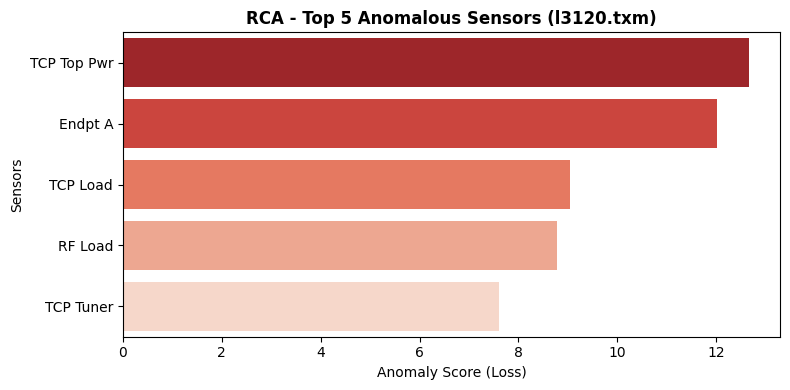

  1위. TCP Top Pwr: 12.6565
  2위. Endpt A: 12.0188
  3위. TCP Load: 9.0451
  4위. RF Load: 8.7773
  5위. TCP Tuner: 7.5963

 [2/21] 웨이퍼 검사: l3121.txm

 🏭 Wafer Analysis Report: [ l3121.txm ]
▶ Wafer Anomaly Score: 3.6889 (기준 임계값: 3.2888)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


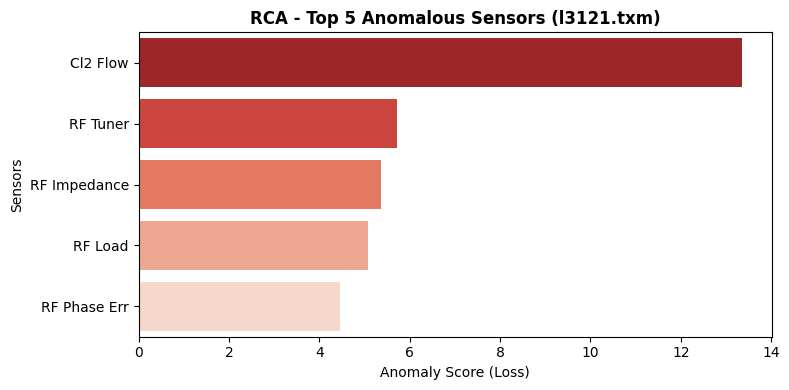

  1위. Cl2 Flow: 13.3484
  2위. RF Tuner: 5.7092
  3위. RF Impedance: 5.3715
  4위. RF Load: 5.0858
  5위. RF Phase Err: 4.4684

 [3/21] 웨이퍼 검사: l3122.txm

 🏭 Wafer Analysis Report: [ l3122.txm ]
▶ Wafer Anomaly Score: 3.4281 (기준 임계값: 3.2888)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


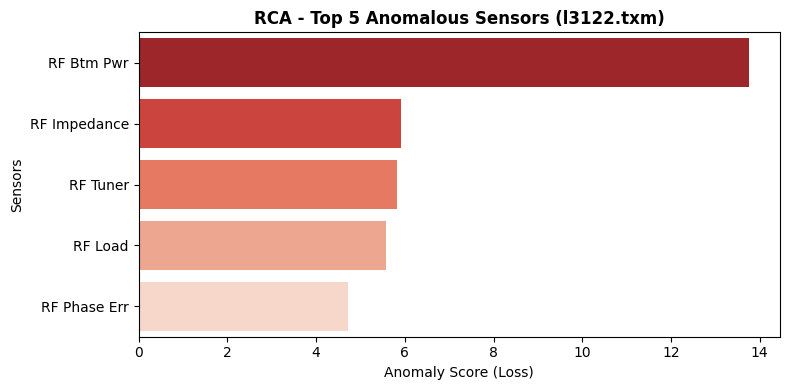

  1위. RF Btm Pwr: 13.7682
  2위. RF Impedance: 5.9144
  3위. RF Tuner: 5.8360
  4위. RF Load: 5.5820
  5위. RF Phase Err: 4.7182
  ✅ [4/21] l3126.txm : 정상 통과 (Score: 2.7919)
  ✅ [5/21] l3127.txm : 정상 통과 (Score: 3.0426)
  ✅ [6/21] l3128.txm : 정상 통과 (Score: 3.0920)
  ✅ [7/21] l3129.txm : 정상 통과 (Score: 2.7762)
  ✅ [8/21] l3130.txm : 정상 통과 (Score: 3.0624)
  ✅ [9/21] l3131.txm : 정상 통과 (Score: 2.9957)
  ✅ [10/21] l3132.txm : 정상 통과 (Score: 3.0598)
  ✅ [11/21] l3133.txm : 정상 통과 (Score: 2.9619)
  ✅ [12/21] l3134.txm : 정상 통과 (Score: 2.8404)
  ✅ [13/21] l3135.txm : 정상 통과 (Score: 2.9474)
  ✅ [14/21] l3136.txm : 정상 통과 (Score: 2.9716)
  ✅ [15/21] l3137.txm : 정상 통과 (Score: 2.9396)
  ✅ [16/21] l3138.txm : 정상 통과 (Score: 3.0623)
  ✅ [17/21] l3139.txm : 정상 통과 (Score: 3.1745)
  ✅ [18/21] l3140.txm : 정상 통과 (Score: 3.1204)

 [19/21] 웨이퍼 검사: l3141.txm

 🏭 Wafer Analysis Report: [ l3141.txm ]
▶ Wafer Anomaly Score: 5.1978 (기준 임계값: 3.2888)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------

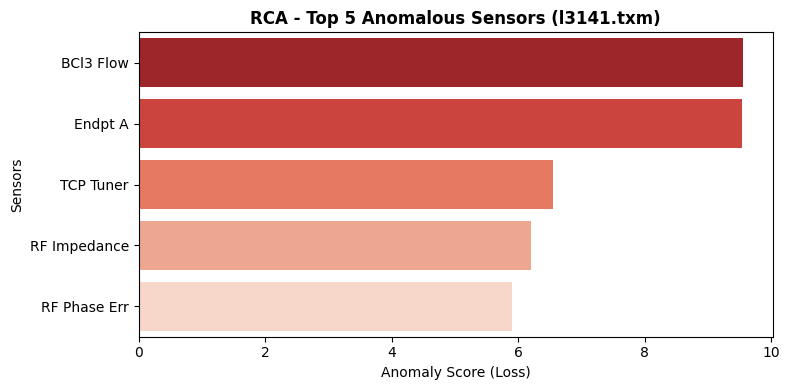

  1위. BCl3 Flow: 9.5496
  2위. Endpt A: 9.5379
  3위. TCP Tuner: 6.5536
  4위. RF Impedance: 6.1993
  5위. RF Phase Err: 5.9087

 [20/21] 웨이퍼 검사: l3142.txm

 🏭 Wafer Analysis Report: [ l3142.txm ]
▶ Wafer Anomaly Score: 4.6320 (기준 임계값: 3.2888)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


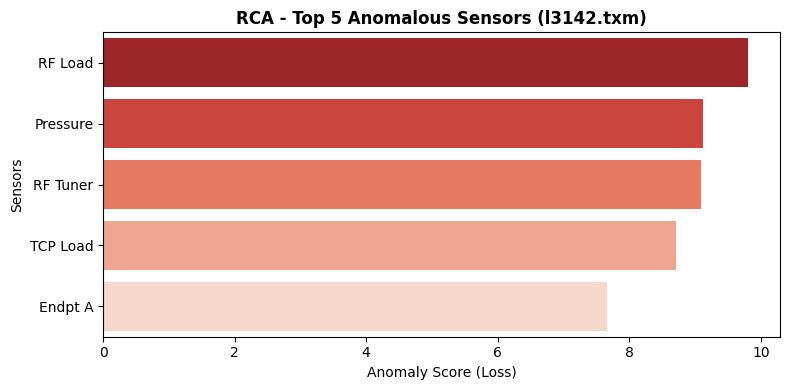

  1위. RF Load: 9.8010
  2위. Pressure: 9.1178
  3위. RF Tuner: 9.0895
  4위. TCP Load: 8.7120
  5위. Endpt A: 7.6545

 [21/21] 웨이퍼 검사: l3143.txm

 🏭 Wafer Analysis Report: [ l3143.txm ]
▶ Wafer Anomaly Score: 4.2108 (기준 임계값: 3.2888)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


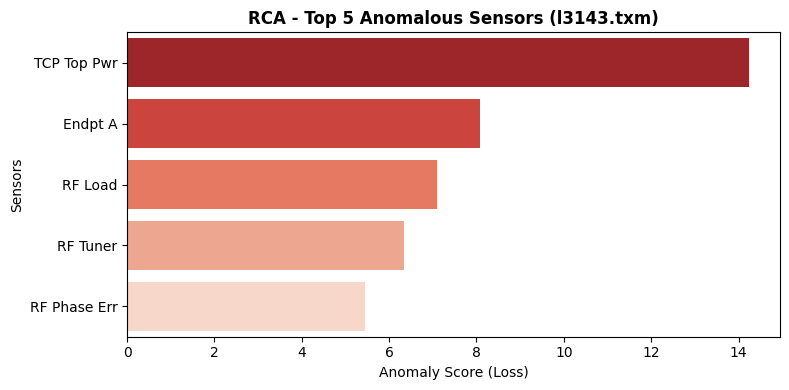

  1위. TCP Top Pwr: 14.2373
  2위. Endpt A: 8.0784
  3위. RF Load: 7.0919
  4위. RF Tuner: 6.3444
  5위. RF Phase Err: 5.4379

  [l31] 실험군 테스트셋 분석 요약 보고서
 - 전체 분석 대상: 21개
 -  최종 정상(Normal) 판정: 15개
 -  최종 불량(Fault) 판정: 6개


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [l33] 실험군 전체 테스트셋 분석 시작
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ 모델 로드 성공! (Threshold: 3.0942)
▶ 타겟 데이터: 정상 15개 | 불량 6개 (총 분석 대상: 21개)


 [1/21] 웨이퍼 검사: l3318.txm

 🏭 Wafer Analysis Report: [ l3318.txm ]
▶ Wafer Anomaly Score: 4.0721 (기준 임계값: 3.0942)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


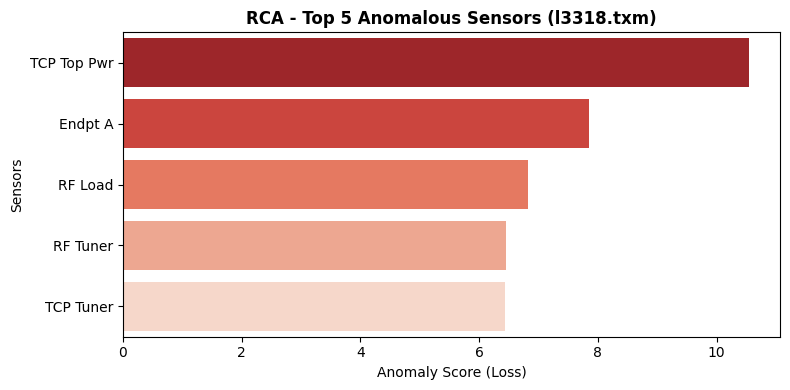

  1위. TCP Top Pwr: 10.5414
  2위. Endpt A: 7.8487
  3위. RF Load: 6.8183
  4위. RF Tuner: 6.4542
  5위. TCP Tuner: 6.4355

 [2/21] 웨이퍼 검사: l3319.txm

 🏭 Wafer Analysis Report: [ l3319.txm ]
▶ Wafer Anomaly Score: 4.1036 (기준 임계값: 3.0942)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


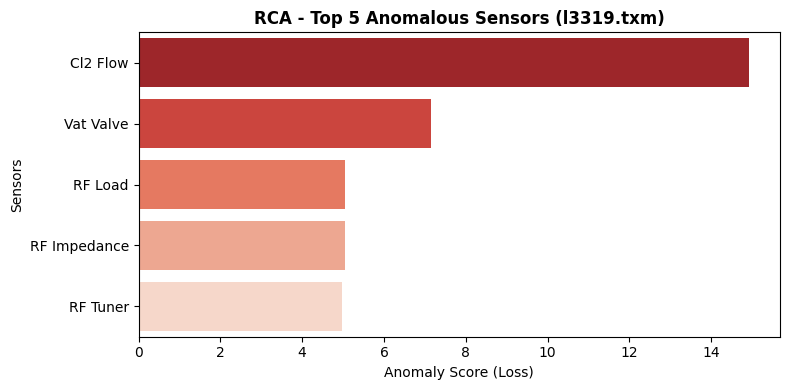

  1위. Cl2 Flow: 14.9359
  2위. Vat Valve: 7.1611
  3위. RF Load: 5.0449
  4위. RF Impedance: 5.0429
  5위. RF Tuner: 4.9860

 [3/21] 웨이퍼 검사: l3320.txm

 🏭 Wafer Analysis Report: [ l3320.txm ]
▶ Wafer Anomaly Score: 3.3674 (기준 임계값: 3.0942)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


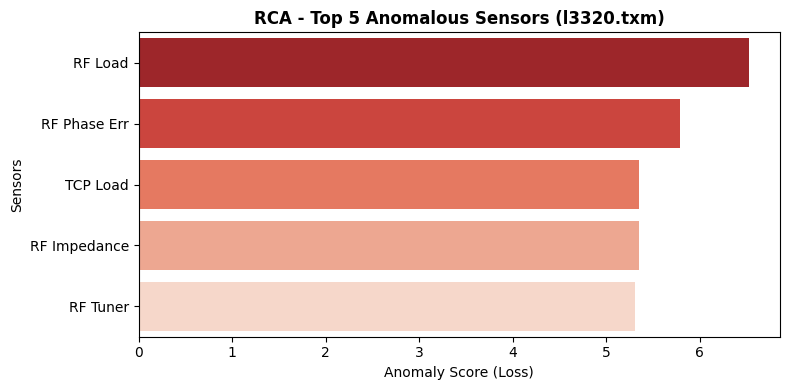

  1위. RF Load: 6.5327
  2위. RF Phase Err: 5.7902
  3위. TCP Load: 5.3545
  4위. RF Impedance: 5.3500
  5위. RF Tuner: 5.3121
  ✅ [4/21] l3326.txm : 정상 통과 (Score: 3.0321)
  ✅ [5/21] l3327.txm : 정상 통과 (Score: 2.6956)
  ✅ [6/21] l3328.txm : 정상 통과 (Score: 2.7364)
  ✅ [7/21] l3329.txm : 정상 통과 (Score: 2.8007)
  ✅ [8/21] l3330.txm : 정상 통과 (Score: 2.8342)
  ✅ [9/21] l3331.txm : 정상 통과 (Score: 2.7851)
  ✅ [10/21] l3332.txm : 정상 통과 (Score: 2.7723)
  ✅ [11/21] l3333.txm : 정상 통과 (Score: 2.7002)
  ✅ [12/21] l3334.txm : 정상 통과 (Score: 2.9098)
  ✅ [13/21] l3335.txm : 정상 통과 (Score: 2.7825)
  ✅ [14/21] l3336.txm : 정상 통과 (Score: 2.8535)
  ✅ [15/21] l3337.txm : 정상 통과 (Score: 2.7445)
  ✅ [16/21] l3338.txm : 정상 통과 (Score: 2.8315)

 [17/21] 웨이퍼 검사: l3339.txm

 🏭 Wafer Analysis Report: [ l3339.txm ]
▶ Wafer Anomaly Score: 4.7381 (기준 임계값: 3.0942)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


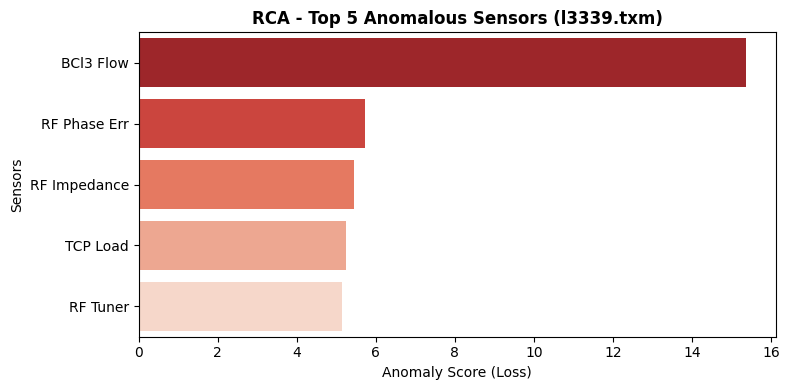

  1위. BCl3 Flow: 15.3641
  2위. RF Phase Err: 5.7195
  3위. RF Impedance: 5.4637
  4위. TCP Load: 5.2548
  5위. RF Tuner: 5.1493

 [18/21] 웨이퍼 검사: l3340.txm

 🏭 Wafer Analysis Report: [ l3340.txm ]
▶ Wafer Anomaly Score: 3.9660 (기준 임계값: 3.0942)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


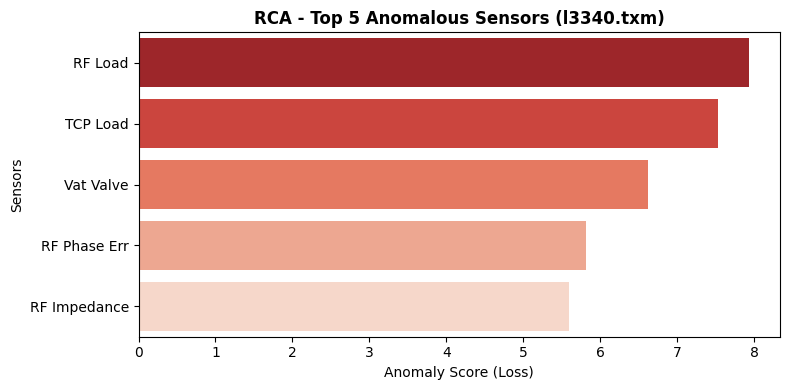

  1위. RF Load: 7.9388
  2위. TCP Load: 7.5349
  3위. Vat Valve: 6.6183
  4위. RF Phase Err: 5.8090
  5위. RF Impedance: 5.5897

 [19/21] 웨이퍼 검사: l3341.txm

 🏭 Wafer Analysis Report: [ l3341.txm ]
▶ Wafer Anomaly Score: 4.6234 (기준 임계값: 3.0942)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


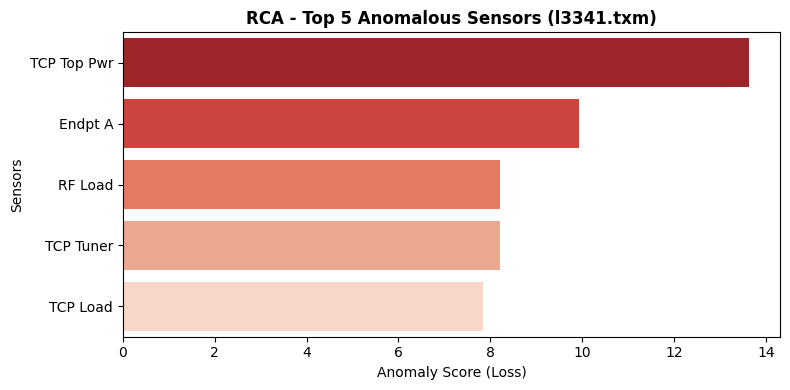

  1위. TCP Top Pwr: 13.6283
  2위. Endpt A: 9.9293
  3위. RF Load: 8.2128
  4위. TCP Tuner: 8.2081
  5위. TCP Load: 7.8347

 [20/21] 웨이퍼 검사: l3342.txm

 🏭 Wafer Analysis Report: [ l3342.txm ]
▶ Wafer Anomaly Score: 3.1865 (기준 임계값: 3.0942)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


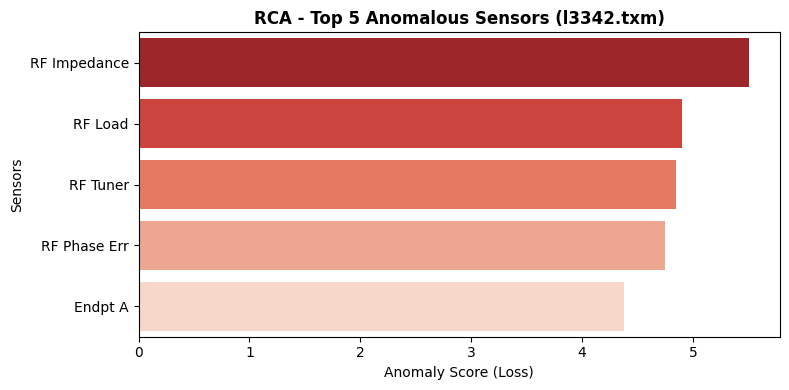

  1위. RF Impedance: 5.5093
  2위. RF Load: 4.9051
  3위. RF Tuner: 4.8438
  4위. RF Phase Err: 4.7457
  5위. Endpt A: 4.3753
  ✅ [21/21] l3343.txm : 정상 통과 (Score: 2.9426)

  [l33] 실험군 테스트셋 분석 요약 보고서
 - 전체 분석 대상: 21개
 -  최종 정상(Normal) 판정: 14개
 -  최종 불량(Fault) 판정: 7개



In [4]:
import os
import torch
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. 통합 분석 설정 및 원본 데이터 (1회 로드 최적화)
# =====================================================================
TARGET_EXP_IDS = ['l29', 'l31', 'l33']   #  순회할 실험군 리스트 지정
save_dir = "/content/drive/MyDrive/ASK_2026_FDC/Code/최종 코드/Saved"
data_file_path = "/content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx"

print(f" 거대 원본 데이터 로드 중 (1회만 수행됩니다): {data_file_path}")
raw_df = pd.read_excel(data_file_path) if data_file_path.endswith('.xlsx') else pd.read_csv(data_file_path)
print(" 원본 데이터 로드 완료!\n")

# =====================================================================
# 2. 각 실험군별 자동 순회 루프
# =====================================================================
for TARGET_EXP_ID in TARGET_EXP_IDS:
    print(f"\n" + "━"*80)
    print(f"  [{TARGET_EXP_ID}] 실험군 전체 테스트셋 분석 시작")
    print("━"*80)

    model_path = f"{save_dir}/trace_gpt_{TARGET_EXP_ID}.pth"
    meta_path = f"{save_dir}/metadata_{TARGET_EXP_ID}.pkl"

    if not os.path.exists(model_path) or not os.path.exists(meta_path):
        print(f"❌ [{TARGET_EXP_ID}] 저장된 모델이나 메타데이터가 없습니다. 건너뜁니다.")
        continue

    # -----------------------------------------------------------------
    # (1) 메타데이터 및 모델 로드
    # -----------------------------------------------------------------
    with open(meta_path, 'rb') as f:
        loaded_meta = pickle.load(f)

    config = loaded_meta['config']
    threshold = loaded_meta['threshold']
    sensor_cols = loaded_meta['sensor_cols']
    scaler = loaded_meta['scaler']
    SEQ_LEN = 32

    # 해당 실험군의 정상/불량 웨이퍼 ID 목록 추출 및 병합
    normal_wafers = np.unique(loaded_meta['ids_test_norm'])
    fault_wafers = np.unique(loaded_meta['ids_test_fault'])
    all_test_wafers = np.concatenate([normal_wafers, fault_wafers])
    unique_test_wafers = np.unique(all_test_wafers)
    total_count = len(unique_test_wafers)

    print(f"✅ 모델 로드 성공! (Threshold: {threshold:.4f})")
    print(f"▶ 타겟 데이터: 정상 {len(normal_wafers)}개 | 불량 {len(fault_wafers)}개 (총 분석 대상: {total_count}개)\n")

    # 모델 가중치 주입
    loaded_model = TRACE_GPT(
        num_sensors=len(sensor_cols), seq_len=SEQ_LEN-1,
        d_model=config['d_model'], resolution=config['resolution']
    ).to(device)
    loaded_model.load_state_dict(torch.load(model_path, map_location=device))
    loaded_model.eval()

    # -----------------------------------------------------------------
    # (2) 웨이퍼 순회하며 개별 판별 및 RCA 수행
    # -----------------------------------------------------------------
    normal_count = 0
    fault_count = 0
    not_found_count = 0

    for i, wafer_id in enumerate(unique_test_wafers, 1):
        target_df = raw_df[raw_df['Wafer_ID'] == wafer_id]

        if target_df.empty:
            print(f"  ❌ [{i}/{total_count}] 원본 데이터 누락: '{wafer_id}'")
            not_found_count += 1
            continue

        target_tensor = preprocess_and_window(target_df, sensor_cols, SEQ_LEN, scaler)

        if target_tensor is not None:
            target_tensor = target_tensor.to(device)

            # 오차 점수 산출
            window_scores = trace_calculate_window_scores(loaded_model, target_tensor, device, batch_size=32, resolution=config['resolution'])
            wafer_score = np.max(window_scores)

            # 합불 판정
            if wafer_score > threshold:
                fault_count += 1
                print(f"\n [{i}/{total_count}] 웨이퍼 검사: {wafer_id}")
                # 불량일 경우 analyze_single_wafer 함수를 호출하여 시각화 및 RCA 진행
                analyze_single_wafer(
                    model=loaded_model,
                    wafer_tensor=target_tensor,
                    wafer_id=wafer_id,
                    threshold=threshold,
                    sensor_cols=sensor_cols,
                    device=device,
                    resolution=config['resolution']
                )
            else:
                normal_count += 1
                # 출력 창이 너무 지저분해지지 않도록 정상일 때는 한 줄만 간결하게 표시
                print(f"  ✅ [{i}/{total_count}] {wafer_id} : 정상 통과 (Score: {wafer_score:.4f})")

    # -----------------------------------------------------------------
    # (3) 해당 실험군 요약 보고서
    # -----------------------------------------------------------------
    print(f"\n" + "="*60)
    print(f"  [{TARGET_EXP_ID}] 실험군 테스트셋 분석 요약 보고서")
    print("="*60)
    print(f" - 전체 분석 대상: {total_count}개")
    print(f" -  최종 정상(Normal) 판정: {normal_count}개")
    print(f" -  최종 불량(Fault) 판정: {fault_count}개")
    if not_found_count > 0:
        print(f" - ❌ 데이터 누락(Skip): {not_found_count}개")
    print("="*60 + "\n")

In [5]:
import pickle
import numpy as np

TARGET_EXP_ID = 'l33'
save_dir = "/content/drive/MyDrive/ASK_2026_FDC/Code/최종 코드/Saved"


model_path = f"{save_dir}/trace_gpt_{TARGET_EXP_ID}.pth"
meta_path = f"{save_dir}/metadata_{TARGET_EXP_ID}.pkl"

with open(meta_path, 'rb') as f:
    loaded_meta = pickle.load(f)

# 정상 웨이퍼 ID 목록 출력
normal_wafers = np.unique(loaded_meta['ids_test_norm'])
print(f"✅ [{TARGET_EXP_ID} 실험군] 테스트용 정상 웨이퍼 목록 (총 {len(normal_wafers)}개):")
print(normal_wafers)

print("-" * 50)

# 덤으로 불량 웨이퍼 ID 목록도 출력해보기
fault_wafers = np.unique(loaded_meta['ids_test_fault'])
print(f"🚨 [{TARGET_EXP_ID} 실험군] 테스트용 불량 웨이퍼 목록 (총 {len(fault_wafers)}개):")
print(fault_wafers)

✅ [l33 실험군] 테스트용 정상 웨이퍼 목록 (총 15개):
['l3326.txm' 'l3327.txm' 'l3328.txm' 'l3329.txm' 'l3330.txm' 'l3331.txm'
 'l3332.txm' 'l3333.txm' 'l3334.txm' 'l3335.txm' 'l3336.txm' 'l3337.txm'
 'l3338.txm' 'l3342.txm' 'l3343.txm']
--------------------------------------------------
🚨 [l33 실험군] 테스트용 불량 웨이퍼 목록 (총 6개):
['l3318.txm' 'l3319.txm' 'l3320.txm' 'l3339.txm' 'l3340.txm' 'l3341.txm']


원본 데이터 로드 중: /content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx
⚙️ 데이터 스케일링 및 슬라이딩 윈도우 변환 중...

 🏭 Wafer Analysis Report: [ l2915.txm ]
▶ Wafer Anomaly Score: 5.0887 (기준 임계값: 3.0773)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


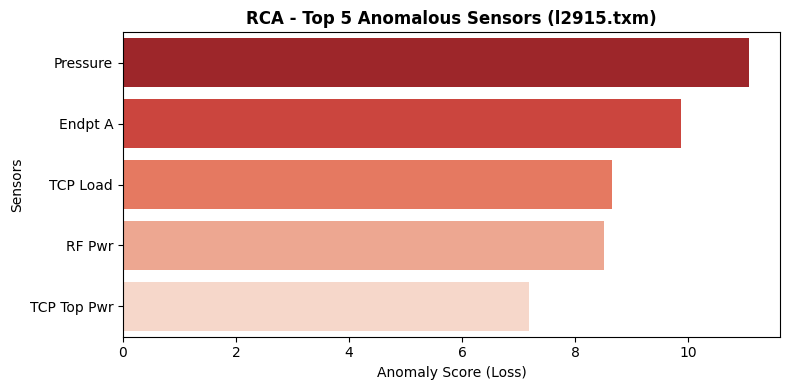

  1위. Pressure: 11.0715
  2위. Endpt A: 9.8741
  3위. TCP Load: 8.6529
  4위. RF Pwr: 8.5163
  5위. TCP Top Pwr: 7.1891


In [33]:
TARGET_EXP_ID = 'l33'
TARGET_WAFER = 'l2915.txm'
save_dir = "/content/drive/MyDrive/ASK_2026_FDC/Code/최종 코드/Saved"
data_file_path = "/content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx" # 원본 데이터 경로

model_path = f"{save_dir}/trace_gpt_{TARGET_EXP_ID}.pth"
meta_path = f"{save_dir}/metadata_{TARGET_EXP_ID}.pkl"

if not os.path.exists(model_path) or not os.path.exists(meta_path):
    print("❌ 저장된 모델/메타데이터가 없습니다.")
else:
    # 1. 메타데이터 (Threshold, Scaler 포함) 로드
    with open(meta_path, 'rb') as f:
        loaded_meta = pickle.load(f)

    config = loaded_meta['config']
    threshold = loaded_meta['threshold']
    sensor_cols = loaded_meta['sensor_cols']
    scaler = loaded_meta['scaler']
    SEQ_LEN = 32

    # 2. 모델 로드 및 가중치 주입
    loaded_model = TRACE_GPT(
        num_sensors=len(sensor_cols), seq_len=SEQ_LEN-1,
        d_model=config['d_model'], resolution=config['resolution']
    ).to(device)
    loaded_model.load_state_dict(torch.load(model_path, map_location=device))
    loaded_model.eval()

    # 3. 원본 데이터에서 타겟 웨이퍼 Raw Data 추출
    print(f"원본 데이터 로드 중: {data_file_path}")
    raw_df = pd.read_excel(data_file_path) if data_file_path.endswith('.xlsx') else pd.read_csv(data_file_path)
    target_df = raw_df[raw_df['Wafer_ID'] == TARGET_WAFER]

    if target_df.empty:
        print(f"❌ 원본 데이터에서 '{TARGET_WAFER}' 웨이퍼를 찾을 수 없습니다.")
    else:
        # 4. 실시간 전처리 (Scaling & Windowing)
        print("⚙️ 데이터 스케일링 및 슬라이딩 윈도우 변환 중...")
        target_tensor = preprocess_and_window(target_df, sensor_cols, SEQ_LEN, scaler)

        # 5. 분석 실행
        if target_tensor is not None:
            target_tensor = target_tensor.to(device)
            analyze_single_wafer(
                model=loaded_model,
                wafer_tensor=target_tensor,
                wafer_id=TARGET_WAFER,
                threshold=threshold,
                sensor_cols=sensor_cols,
                device=device,
                resolution=config['resolution']
            )


 🚀 [l33] 실험군의 전체 테스트셋 분석 시작
총 분석 대상 웨이퍼 개수: 21개


[1/21] 웨이퍼 검사 중: l3318.txm

 🏭 Wafer Analysis Report: [ l3318.txm ]
▶ Wafer Anomaly Score: 4.0819 (기준 임계값: 3.0773)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


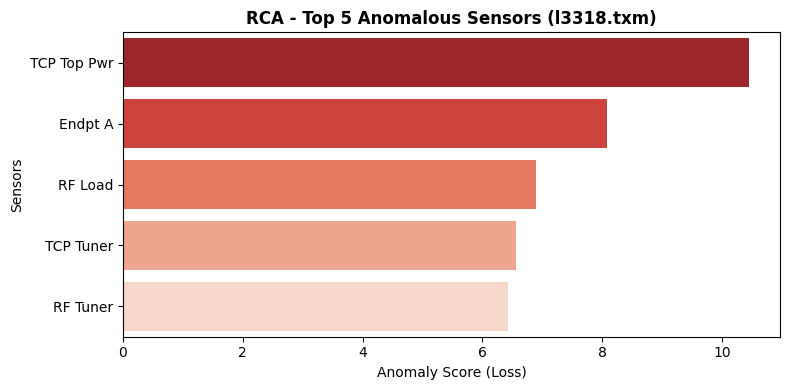

  1위. TCP Top Pwr: 10.4454
  2위. Endpt A: 8.0882
  3위. RF Load: 6.9008
  4위. TCP Tuner: 6.5628
  5위. RF Tuner: 6.4280

[2/21] 웨이퍼 검사 중: l3319.txm

 🏭 Wafer Analysis Report: [ l3319.txm ]
▶ Wafer Anomaly Score: 3.9276 (기준 임계값: 3.0773)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


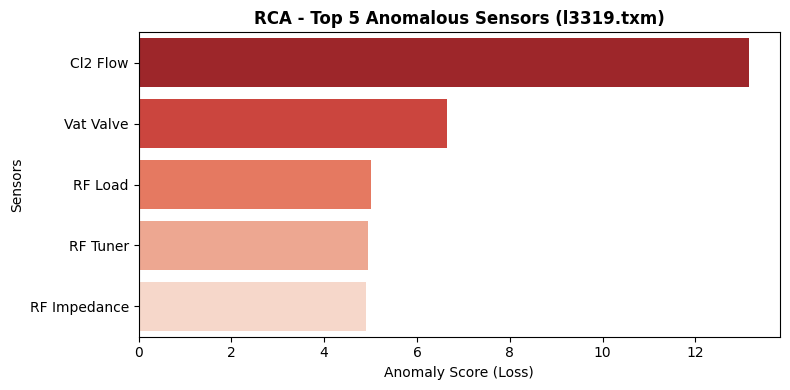

  1위. Cl2 Flow: 13.1651
  2위. Vat Valve: 6.6370
  3위. RF Load: 4.9997
  4위. RF Tuner: 4.9365
  5위. RF Impedance: 4.8952

[3/21] 웨이퍼 검사 중: l3320.txm

 🏭 Wafer Analysis Report: [ l3320.txm ]
▶ Wafer Anomaly Score: 3.3015 (기준 임계값: 3.0773)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


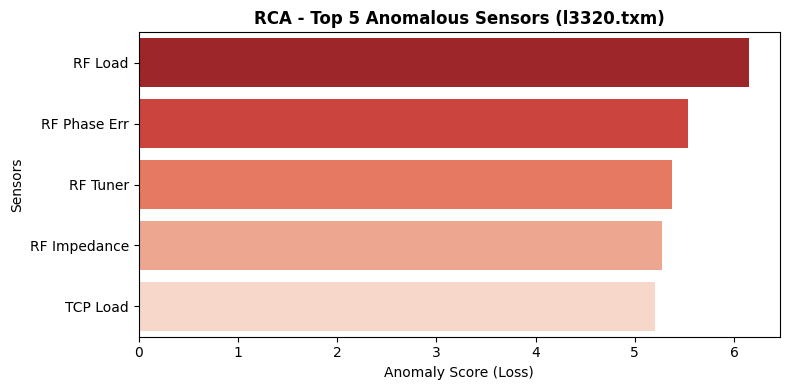

  1위. RF Load: 6.1557
  2위. RF Phase Err: 5.5398
  3위. RF Tuner: 5.3802
  4위. RF Impedance: 5.2747
  5위. TCP Load: 5.2024

[4/21] 웨이퍼 검사 중: l3326.txm
  ▶ 판정: ✅ 정상 (Score: 2.9821, Threshold: 3.0773)

[5/21] 웨이퍼 검사 중: l3327.txm
  ▶ 판정: ✅ 정상 (Score: 2.7283, Threshold: 3.0773)

[6/21] 웨이퍼 검사 중: l3328.txm
  ▶ 판정: ✅ 정상 (Score: 2.6980, Threshold: 3.0773)

[7/21] 웨이퍼 검사 중: l3329.txm
  ▶ 판정: ✅ 정상 (Score: 2.8208, Threshold: 3.0773)

[8/21] 웨이퍼 검사 중: l3330.txm
  ▶ 판정: ✅ 정상 (Score: 2.8142, Threshold: 3.0773)

[9/21] 웨이퍼 검사 중: l3331.txm
  ▶ 판정: ✅ 정상 (Score: 2.8093, Threshold: 3.0773)

[10/21] 웨이퍼 검사 중: l3332.txm
  ▶ 판정: ✅ 정상 (Score: 2.7912, Threshold: 3.0773)

[11/21] 웨이퍼 검사 중: l3333.txm
  ▶ 판정: ✅ 정상 (Score: 2.6761, Threshold: 3.0773)

[12/21] 웨이퍼 검사 중: l3334.txm
  ▶ 판정: ✅ 정상 (Score: 2.9329, Threshold: 3.0773)

[13/21] 웨이퍼 검사 중: l3335.txm
  ▶ 판정: ✅ 정상 (Score: 2.7982, Threshold: 3.0773)

[14/21] 웨이퍼 검사 중: l3336.txm
  ▶ 판정: ✅ 정상 (Score: 2.8028, Threshold: 3.0773)

[15/21] 웨이퍼 검사 중: l3337.txm
  ▶ 판정: 

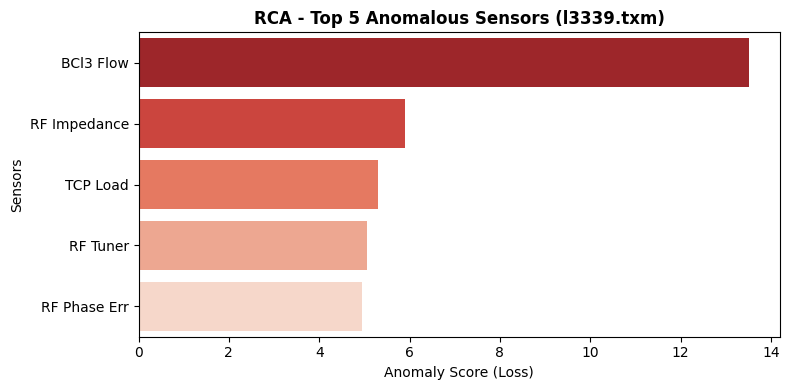

  1위. BCl3 Flow: 13.5147
  2위. RF Impedance: 5.8902
  3위. TCP Load: 5.2927
  4위. RF Tuner: 5.0549
  5위. RF Phase Err: 4.9385

[18/21] 웨이퍼 검사 중: l3340.txm

 🏭 Wafer Analysis Report: [ l3340.txm ]
▶ Wafer Anomaly Score: 3.7679 (기준 임계값: 3.0773)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


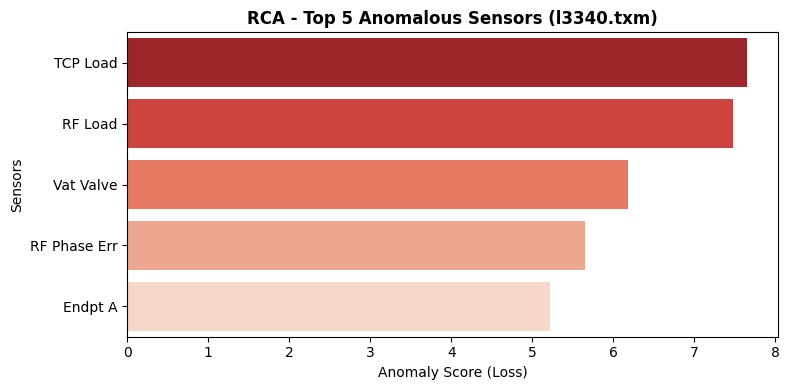

  1위. TCP Load: 7.6545
  2위. RF Load: 7.4772
  3위. Vat Valve: 6.1754
  4위. RF Phase Err: 5.6554
  5위. Endpt A: 5.2212

[19/21] 웨이퍼 검사 중: l3341.txm

 🏭 Wafer Analysis Report: [ l3341.txm ]
▶ Wafer Anomaly Score: 4.3547 (기준 임계값: 3.0773)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


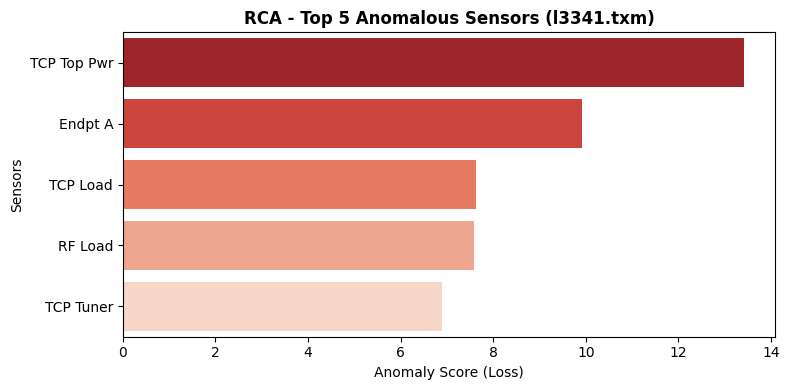

  1위. TCP Top Pwr: 13.4168
  2위. Endpt A: 9.9219
  3위. TCP Load: 7.6367
  4위. RF Load: 7.5945
  5위. TCP Tuner: 6.9017

[20/21] 웨이퍼 검사 중: l3342.txm

 🏭 Wafer Analysis Report: [ l3342.txm ]
▶ Wafer Anomaly Score: 3.0990 (기준 임계값: 3.0773)
▶ 판정: 불량 (Fault) 감지
-------------------------------------------------------
[Root Cause Analysis]


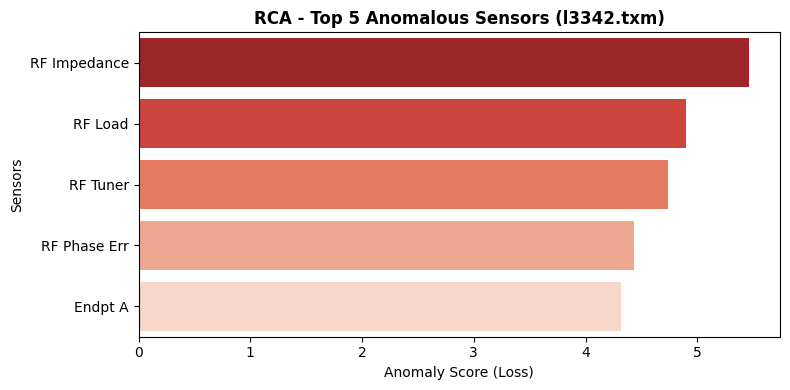

  1위. RF Impedance: 5.4671
  2위. RF Load: 4.8984
  3위. RF Tuner: 4.7374
  4위. RF Phase Err: 4.4336
  5위. Endpt A: 4.3198

[21/21] 웨이퍼 검사 중: l3343.txm
  ▶ 판정: ✅ 정상 (Score: 2.9223, Threshold: 3.0773)

 📊 [l33] 실험군 테스트셋 분석 요약 보고서
 - 전체 분석 대상: 21개
 - ✅ 정상 (Normal) 판정: 14개
 - 🚨 불량 (Fault) 판정: 7개



In [34]:
# =====================================================================
# [추가 코드] 전체 테스트 웨이퍼 자동 순회 및 판별 (Batch Analysis)
# =====================================================================
print(f"\n" + "="*60)
print(f" 🚀 [{TARGET_EXP_ID}] 실험군의 전체 테스트셋 분석 시작")
print("="*60)

# 1. 메타데이터에서 테스트셋에 사용된 웨이퍼 ID 목록 추출
# (정상 웨이퍼와 불량 웨이퍼 ID를 모두 합칩니다)
all_test_wafers = np.concatenate([loaded_meta['ids_test_norm'], loaded_meta['ids_test_fault']])

# np.unique()를 사용하면 중복을 제거하고 정렬된 고유 ID 목록을 얻을 수 있습니다.
unique_test_wafers = np.unique(all_test_wafers)

print(f"총 분석 대상 웨이퍼 개수: {len(unique_test_wafers)}개\n")

# 2. 결과 통계를 저장할 변수 초기화
total_count = len(unique_test_wafers)
normal_count = 0
fault_count = 0
not_found_count = 0

# 3. 각 웨이퍼 ID별로 순회하며 분석 실행
for i, wafer_id in enumerate(unique_test_wafers, 1):
    print(f"\n[{i}/{total_count}] 웨이퍼 검사 중: {wafer_id}")

    # 원본 데이터에서 해당 웨이퍼 데이터 추출
    target_df = raw_df[raw_df['Wafer_ID'] == wafer_id]

    if target_df.empty:
        print(f"  ❌ 원본 데이터에서 '{wafer_id}'를 찾을 수 없습니다. 건너뜁니다.")
        not_found_count += 1
        continue

    # 전처리 (스케일링 및 슬라이딩 윈도우)
    target_tensor = preprocess_and_window(target_df, sensor_cols, SEQ_LEN, scaler)

    if target_tensor is not None:
        target_tensor = target_tensor.to(device)

        # 임계값과 비교하여 결과 판별을 위해 점수를 먼저 계산
        window_scores = trace_calculate_window_scores(loaded_model, target_tensor, device, batch_size=32, resolution=config['resolution'])
        wafer_score = np.max(window_scores)

        if wafer_score > threshold:
            fault_count += 1
            # 불량일 경우 analyze_single_wafer 함수를 호출하여 시각화 및 RCA 진행
            analyze_single_wafer(
                model=loaded_model,
                wafer_tensor=target_tensor,
                wafer_id=wafer_id,
                threshold=threshold,
                sensor_cols=sensor_cols,
                device=device,
                resolution=config['resolution']
            )
        else:
            normal_count += 1
            # 정상인 경우 간단한 메시지만 출력 (RCA 생략)
            print(f"  ▶ 판정: ✅ 정상 (Score: {wafer_score:.4f}, Threshold: {threshold:.4f})")

# 4. 최종 분석 요약 보고서 출력
print(f"\n" + "="*60)
print(f" 📊 [{TARGET_EXP_ID}] 실험군 테스트셋 분석 요약 보고서")
print("="*60)
print(f" - 전체 분석 대상: {total_count}개")
print(f" - ✅ 정상 (Normal) 판정: {normal_count}개")
print(f" - 🚨 불량 (Fault) 판정: {fault_count}개")
if not_found_count > 0:
    print(f" - ❌ 데이터 누락: {not_found_count}개")
print("="*60 + "\n")